#ML4Net - Lab 2

## Team members

Antoine Metz (335801) | Corentin Le Bris (335776)

## Description

In this lab, you will implement an ML model that detects congestion in Wi-Fi networks. In particular, you will desing and implement a supervised learning model (e.g., linear regression, multi-layer perceptron, neural network), which you will train using a dataset that was generated using the ns-3 simulator.

Each row in the dataset is organized as (x1, x2, ..., x26, y1, y2, ..., y26, s, r, l), where:

* `x1, x2..., x26, y1, y2, ..., y26` represent the histogram of the Inter-Frame Space (IFS) values for M frames that accessed the medium in a 60 seconds observation sample.
  * `x26` represents the maximum IFS duration (in ms) in the considered M frames whereas `x1` is `x26`/26
  * The remaining `xi` values are buckets at uniform spacing between `x1` and `x26`.
  * For i>1, the values of `yi` represent the IFS histogram count (in percentage) for a corresponding bucket interval between `xi`-1 and `xi`.
  * In the case of `y1`, the bucket interval is between 0 and `x1`
* `s` is the average IFS duration (in ms)
* `r` is the percentage of frame collisions
* `l` is the label, where 1 indicates that the network is saturated, and 0, that it is not

Original dataset: https://ieee-dataport.org/documents/dataset-identification-saturated-and-unsaturated-wi-fi-networks

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   Submission deadline: 21 May 2026 (EoB).

## Setting up the environment

1. Connect your Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [2]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip

--2026-05-26 12:21:41--  https://github.com/fwilhelmi/fwilhelmi.github.io/raw/refs/heads/master/files/dataset_Lab2.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip [following]
--2026-05-26 12:21:42--  https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/refs/heads/master/files/dataset_Lab2.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1803279 (1.7M) [application/zip]
Saving to: ‘dataset_Lab2.zip’

dataset_Lab2.zip    100%[===================>]   1.72M  --.-KB/s    in 0.08s   

2026-05-26 12:21:42 (22.3 MB/

3. Define the main path of the code

In [3]:
mypath="drive/MyDrive/AAX/Lab2"

4. Extract the source code to the destination folder

In [4]:
mkdir -p $mypath; cp dataset_Lab2.zip $mypath; cd $mypath; unzip -o dataset_Lab2.zip

Archive:  dataset_Lab2.zip
  inflating: test_data.csv           
  inflating: __MACOSX/._test_data.csv  
  inflating: train_data.csv          
  inflating: __MACOSX/._train_data.csv  


## Visualizing the data




       0       1       2       3       4       5       6       7       8   \
0  0.0065  0.0130  0.0195  0.0260  0.0325  0.0390  0.0455  0.0520  0.0585   
1  0.0263  0.0526  0.0789  0.1052  0.1316  0.1579  0.1842  0.2105  0.2368   
2  0.0176  0.0352  0.0528  0.0704  0.0881  0.1057  0.1233  0.1409  0.1585   
3  0.0222  0.0444  0.0666  0.0888  0.1110  0.1332  0.1554  0.1776  0.1998   
4  0.0189  0.0379  0.0568  0.0758  0.0947  0.1137  0.1326  0.1516  0.1705   

       9   ...      45      46      47      48      49      50      51  \
0  0.0650  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
1  0.2631  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   
2  0.1761  ...  0.0316  0.0368  0.0312  0.0312  0.0316  0.0299  0.0304   
3  0.2220  ...  0.0316  0.0307  0.0312  0.0000  0.0360  0.0364  0.0304   
4  0.1895  ...  0.0316  0.0368  0.0312  0.0000  0.0316  0.0364  0.0304   

       52      53  54  
0  0.0604  0.9960   1  
1  0.0604  0.9960   1  
2  0.0604  0.9957   

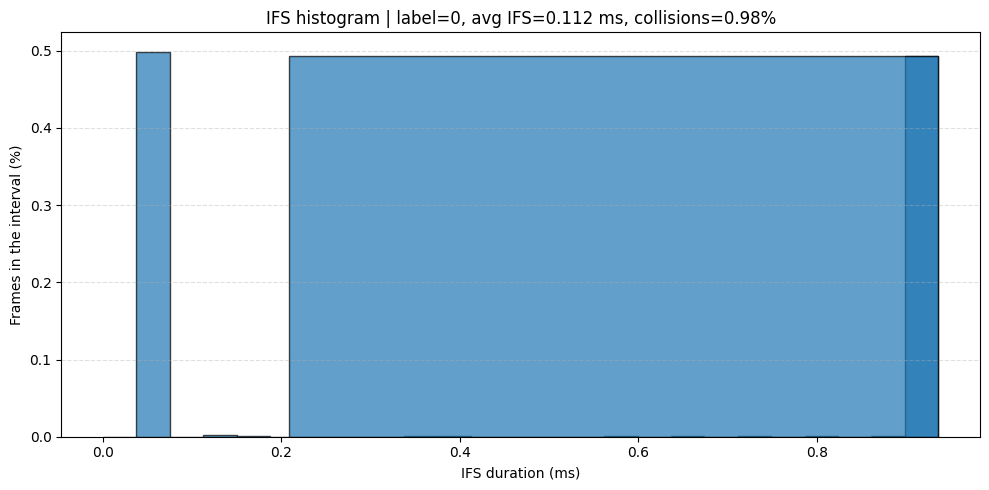

Example for label 1


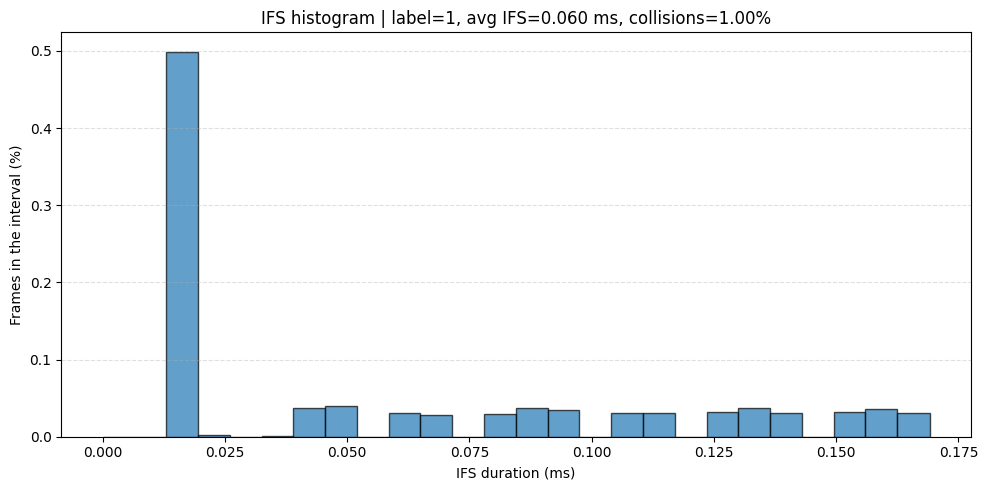

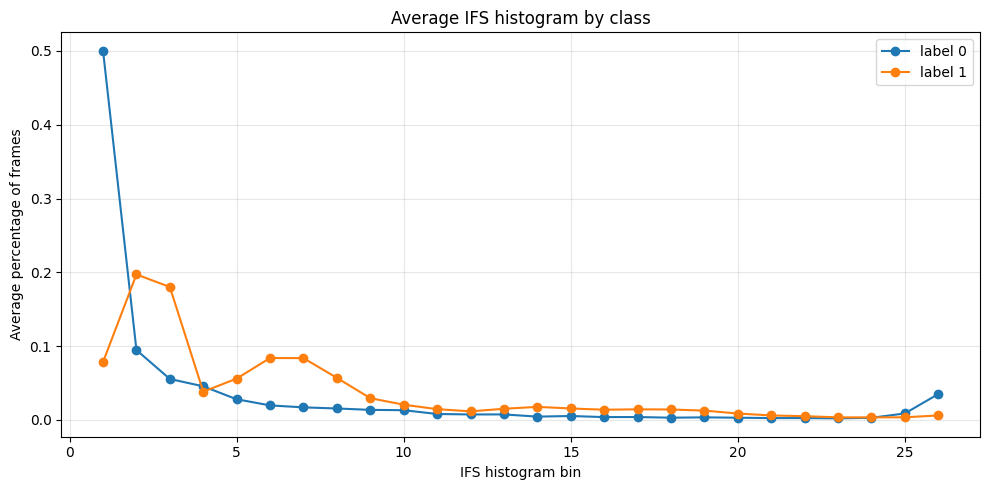

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ifs_histogram(data_row):
    """
    Plot the Inter-Frame Space (IFS) histogram from one dataset row.

    Row format:
    x1...x26 = IFS bin limits
    y1...y26 = percentage of frames in each bin
    s = average IFS duration
    r = percentage of collisions
    l = label, where 1 means saturated and 0 means non-saturated
    """

    # First 26 columns are the IFS bin limits.
    x_values = np.array(data_row[:26], dtype=float)

    # Next 26 columns are the histogram percentages.
    y_counts = np.array(data_row[26:52], dtype=float)

    # The last three values are network indicators and label.
    avg_ifs = float(data_row[52])
    collision_rate = float(data_row[53])
    label = int(data_row[54])

    bin_edges = [0] + list(x_values)

    plt.figure(figsize=(10, 5))
    plt.bar(
        bin_edges[:-1],
        y_counts,
        width=np.diff(bin_edges),
        align='edge',
        alpha=0.7,
        edgecolor="black"
    )

    plt.xlabel("IFS duration (ms)")
    plt.ylabel("Frames in the interval (%)")
    plt.title(
        f"IFS histogram | label={label}, "
        f"avg IFS={avg_ifs:.3f} ms, collisions={collision_rate:.2f}%"
    )
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_average_ifs_by_label(train_data_df):
    """
    Plot the average IFS histogram for each class.
    This gives a clearer view than only looking at one random sample.
    """
    labels = train_data_df.iloc[:, 54].astype(int)
    y_histograms = train_data_df.iloc[:, 26:52].astype(float)

    plt.figure(figsize=(10, 5))

    for label in sorted(labels.unique()):
        mean_histogram = y_histograms[labels == label].mean(axis=0)
        plt.plot(
            range(1, 27),
            mean_histogram,
            marker="o",
            label=f"label {label}"
        )

    plt.xlabel("IFS histogram bin")
    plt.ylabel("Average percentage of frames")
    plt.title("Average IFS histogram by class")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Read the data file.
file_name = mypath + '/train_data.csv'
train_data_df = pd.read_csv(file_name, header=None)
print(train_data_df.head())

# Plot one example from each class to check that the parser works.
for label in sorted(train_data_df.iloc[:, 54].astype(int).unique()):
    row_index = train_data_df[train_data_df.iloc[:, 54] == label].index[0]
    print(f"Example for label {label}")
    plot_ifs_histogram(train_data_df.iloc[row_index].values)

# Plot average class profiles to compare the two situations more directly.
plot_average_ifs_by_label(train_data_df)


**Quick check of the input data**

The first plots are mainly a sanity check. Each row is parsed as an IFS histogram, with the last columns giving the average IFS, the collision percentage and the binary label.

I also plotted one example for each label and the average histogram by class. This is useful because the task is not only to train a classifier, but also to check that the inputs make sense for Wi-Fi congestion detection. The IFS histogram describes the channel access behaviour, so it should contain information about whether the network is saturated or not.

## EXERCISES

### Exercise 1:
Define an approach for training and validating the model you are going to train with the proposed data. Then, perform the split accordingly.

Full training dataset shape: (20000, 55)
Training split: (16000, 54)
Validation split: (4000, 54)


,count,percentage
label,,
0,10001,50.0
1,9999,50.0


avg_ifs_ms                         collision_percentage                  \
            mean     std     min     max                 mean     std     min   
label                                                                           
0         0.4026  0.5500  0.0432  5.7652               0.9810  0.0143  0.8812   
1         0.0518  0.0178  0.0332  0.1790               0.7991  0.1250  0.3307   

               
          max  
label          
0      0.9979  
1      1.0000

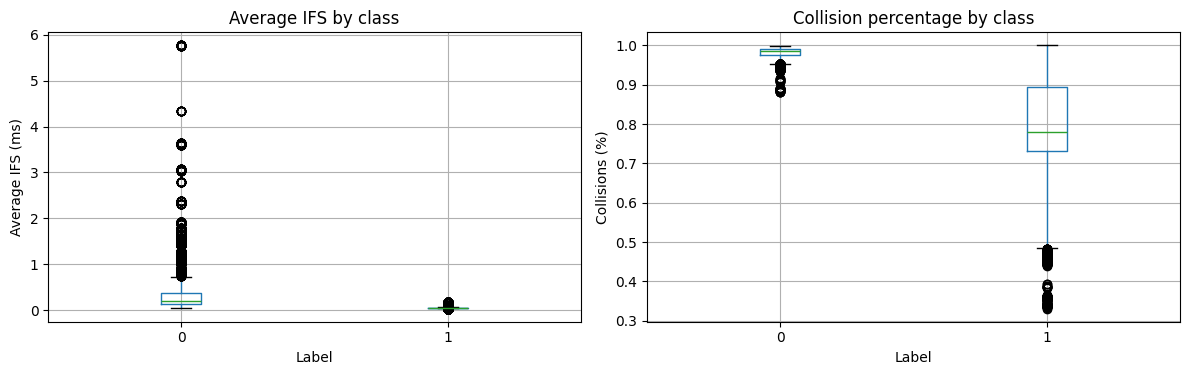

In [6]:
# (response to exercise 1)

from sklearn.model_selection import train_test_split
from IPython.display import display

RANDOM_STATE = 42

# The dataset has 55 columns:
# 26 IFS bin limits, 26 histogram percentages, average IFS, collision rate, and the label.
x_columns = [f"x{i}" for i in range(1, 27)]
y_columns = [f"y{i}" for i in range(1, 27)]
extra_columns = ["avg_ifs_ms", "collision_percentage"]
label_column = "label"

all_columns = x_columns + y_columns + extra_columns + [label_column]

data = train_data_df.copy()
data.columns = all_columns
data[label_column] = data[label_column].astype(int)

feature_columns = x_columns + y_columns + extra_columns

X = data[feature_columns]
y = data[label_column]

# Stratified split keeps approximately the same proportion of saturated/non-saturated
# samples in training and validation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Full training dataset shape:", data.shape)
print("Training split:", X_train.shape)
print("Validation split:", X_val.shape)

class_distribution = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percentage": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})
display(class_distribution)

# Quick network-level statistics by class.
# These variables are useful because saturation should usually affect access delays
# and collisions in the channel.
network_stats = data.groupby(label_column)[extra_columns].agg(["mean", "std", "min", "max"]).round(4)
display(network_stats)

# Visual check of the two most direct network indicators.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data.boxplot(column="avg_ifs_ms", by=label_column, ax=axes[0])
axes[0].set_title("Average IFS by class")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Average IFS (ms)")

data.boxplot(column="collision_percentage", by=label_column, ax=axes[1])
axes[1].set_title("Collision percentage by class")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Collisions (%)")

plt.suptitle("")
plt.tight_layout()
plt.show()


**Exercise 1 analysis**

The training dataset contains **20,000 samples** and **55 columns**. After removing the label column, the model uses **54 input features**.

The split is done with stratification, so the class balance is preserved between training and validation. The full training set is almost perfectly balanced: **10,001 non-saturated samples** and **9,999 saturated samples**, so accuracy is not misleading because of a majority class.

The first statistics already show that the two classes are not distributed in exactly the same way. For example, in this run the mean average IFS is about **0.4026 ms** for label 0 and **0.0518 ms** for label 1. The collision percentage also changes between the two labels. This does not mean that one variable alone is enough, but it confirms that the access-delay and collision-related variables are relevant for the classification task.

### Exercise 2:

Define your ML model, so that it can be called for training and test. Examples of approaches that you could use (but not limited to):

*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Decision Trees or Random Forests
*   Convolutional Neural Network (CNN)

In [7]:
# (response to exercise 2)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Baseline model: useful to check that our ML model really learns something.
dummy_model = DummyClassifier(strategy="most_frequent")

# Linear baseline: simple and interpretable.
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Main model: Random Forest.
# It is a good fit here because it can combine histogram bins, average IFS,
# and collision percentage without assuming a linear decision boundary.
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

models = {
    "Dummy baseline": dummy_model,
    "Logistic regression": logistic_model,
    "Random forest": rf_model
}

print("Models defined:")
for name in models:
    print("-", name)


Models defined:
- Dummy baseline
- Logistic regression
- Random forest


**Exercise 2 analysis**

I kept three models to make the comparison easier to understand. The dummy model is only a baseline: if a real model does not beat it, then it is not learning anything useful. Logistic regression is a simple linear model, so it gives a first serious reference. The Random Forest is used as the main model because the input is a mix of histogram bins and network indicators, and the relation with saturation may not be purely linear.

### Exercise 3:

Define the hyperparameters that you will use to train the model.

In [8]:
# (response to exercise 3)

from sklearn.metrics import log_loss, accuracy_score, f1_score

# Main hyperparameters used for the Random Forest.
# n_estimators is studied in Exercise 4 to show the training/validation evolution.
rf_base_params = {
    "max_depth": None,
    "min_samples_leaf": 2,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

n_estimators_candidates = [10, 25, 50, 100, 150, 200]

print("Random Forest hyperparameters:")
for key, value in rf_base_params.items():
    print(f"{key}: {value}")

print("Candidate numbers of trees:", n_estimators_candidates)


Random Forest hyperparameters:
max_depth: None
min_samples_leaf: 2
class_weight: balanced
random_state: 42
n_jobs: -1
Candidate numbers of trees: [10, 25, 50, 100, 150, 200]


**Exercise 3 analysis**

The most important hyperparameter tested here is the number of trees. I keep the other Random Forest parameters simple: unrestricted depth to let the model capture interactions between bins, `min_samples_leaf=2` to avoid very isolated leaves, and `class_weight="balanced"` even though the classes are already almost balanced.

This is not a very large hyperparameter search, but it is enough to justify the selected model and to avoid choosing the number of trees completely at random.

### Exercise 4:
Train the model and show the procedure (e.g., evolution of the training/validation loss).

,n_estimators,train_log_loss,val_log_loss,train_accuracy,val_accuracy,train_f1,val_f1
0,10,0.0074,0.0193,0.9998,0.9948,0.9997,0.9947
1,25,0.0074,0.0185,0.9999,0.9965,0.9999,0.9965
2,50,0.0069,0.0176,0.9999,0.9965,0.9999,0.9965
3,100,0.0064,0.0160,1.0000,0.9980,1.0000,0.9980
4,150,0.0064,0.0159,1.0000,0.9975,1.0000,0.9975
5,200,0.0064,0.0161,1.0000,0.9985,1.0000,0.9985


Selected number of trees: 150


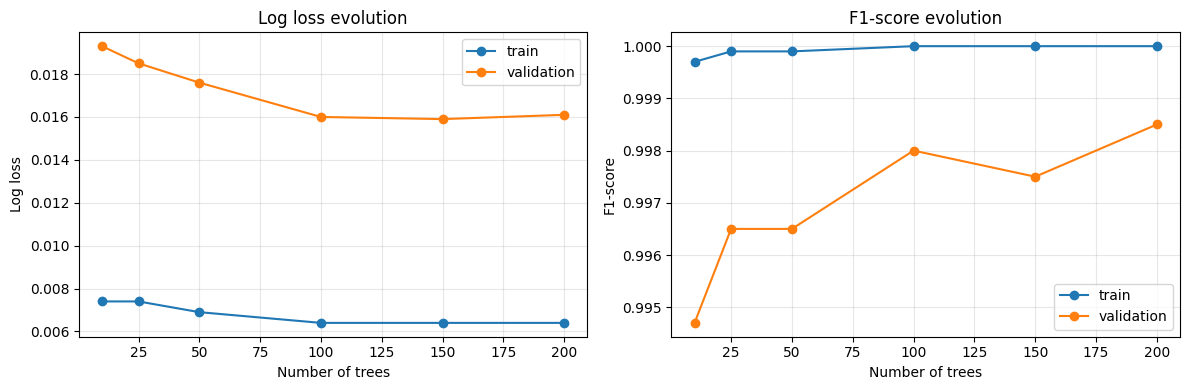

In [9]:
# (response to exercise 4)

from sklearn.metrics import log_loss, accuracy_score, f1_score

# First, train the simple baselines.
dummy_model.fit(X_train, y_train)
logistic_model.fit(X_train, y_train)

# Then, train several Random Forests with more and more trees.
# This gives a simple training/validation curve even if Random Forests do not train
# with gradient descent like neural networks.
history = []

for n_estimators in n_estimators_candidates:
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        **rf_base_params
    )

    model.fit(X_train, y_train)

    train_proba = model.predict_proba(X_train)[:, 1]
    val_proba = model.predict_proba(X_val)[:, 1]

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    history.append({
        "n_estimators": n_estimators,
        "train_log_loss": log_loss(y_train, train_proba),
        "val_log_loss": log_loss(y_val, val_proba),
        "train_accuracy": accuracy_score(y_train, train_pred),
        "val_accuracy": accuracy_score(y_val, val_pred),
        "train_f1": f1_score(y_train, train_pred),
        "val_f1": f1_score(y_val, val_pred)
    })

history_df = pd.DataFrame(history).round(4)
display(history_df)

# Select the model using validation log loss.
best_n_estimators = int(history_df.loc[history_df["val_log_loss"].idxmin(), "n_estimators"])

rf_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    **rf_base_params
)
rf_model.fit(X_train, y_train)

print(f"Selected number of trees: {best_n_estimators}")

# Plot the evolution of loss and F1-score.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["n_estimators"], history_df["train_log_loss"], marker="o", label="train")
axes[0].plot(history_df["n_estimators"], history_df["val_log_loss"], marker="o", label="validation")
axes[0].set_title("Log loss evolution")
axes[0].set_xlabel("Number of trees")
axes[0].set_ylabel("Log loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df["n_estimators"], history_df["train_f1"], marker="o", label="train")
axes[1].plot(history_df["n_estimators"], history_df["val_f1"], marker="o", label="validation")
axes[1].set_title("F1-score evolution")
axes[1].set_xlabel("Number of trees")
axes[1].set_ylabel("F1-score")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


**Exercise 4 analysis**

The validation curve shows that the Random Forest reaches a very high score quickly. With only **10 trees**, the validation F1-score is already about **0.9947**. Increasing the number of trees slightly improves the results and stabilizes the model.

The best validation log loss is obtained with **150 trees** in this run. The training score is almost perfect, but the validation score also remains very high, so there is no obvious sign of strong overfitting from these curves. The difference between 100, 150 and 200 trees is small, so the exact number of trees is not extremely critical here.

### Exercise 5:

Select and define the most appropriate evaluation metric(s). Discuss the appropriateness of your evaluation metrics for the binary classification problem we are considering.

,accuracy,precision,recall,f1_score,roc_auc,average_precision
dataset,,,,,,
Dummy baseline,0.5000,0.0000,0.0000,0.0000,0.5000,0.5000
Logistic regression,0.9788,0.9868,0.9705,0.9786,0.9968,0.9971
Random forest,0.9975,0.9995,0.9955,0.9975,1.0000,1.0000


Classification report for the selected Random Forest on validation set:
              precision    recall  f1-score   support

           0     0.9955    0.9995    0.9975      2000
           1     0.9995    0.9955    0.9975      2000

    accuracy                         0.9975      4000
   macro avg     0.9975    0.9975    0.9975      4000
weighted avg     0.9975    0.9975    0.9975      4000



,predicted non-saturated,predicted saturated
true non-saturated,1999,1
true saturated,9,1991


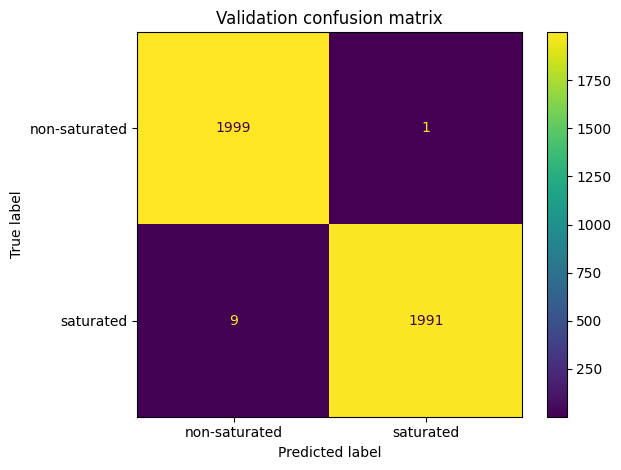

In [10]:
# (response to exercise 5)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_binary_classifier(model, X_data, y_true, dataset_name="dataset"):
    """
    Compute the main metrics for a binary classifier.

    Accuracy is useful as a global score.
    Precision and recall help understand false alarms and missed saturated cases.
    F1-score balances precision and recall.
    ROC-AUC and average precision use predicted probabilities.
    """

    y_pred = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_data)[:, 1]
    else:
        y_score = model.decision_function(X_data)

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score)
    }

    return metrics, y_pred, y_score

validation_results = []

for name, model in {
    "Dummy baseline": dummy_model,
    "Logistic regression": logistic_model,
    "Random forest": rf_model
}.items():
    metrics, _, _ = evaluate_binary_classifier(model, X_val, y_val, dataset_name=name)
    validation_results.append(metrics)

validation_results_df = pd.DataFrame(validation_results).set_index("dataset").round(4)
display(validation_results_df)

print("Classification report for the selected Random Forest on validation set:")
val_metrics, val_pred, val_score = evaluate_binary_classifier(
    rf_model,
    X_val,
    y_val,
    dataset_name="Random forest validation"
)
print(classification_report(y_val, val_pred, digits=4))

cm_val = confusion_matrix(y_val, val_pred)

# Show the matrix as a table and as a plot.
# Rows are true labels, columns are predicted labels.
cm_val_df = pd.DataFrame(
    cm_val,
    index=["true non-saturated", "true saturated"],
    columns=["predicted non-saturated", "predicted saturated"]
)
display(cm_val_df)

ConfusionMatrixDisplay(cm_val, display_labels=["non-saturated", "saturated"]).plot(values_format="d")
plt.title("Validation confusion matrix")
plt.tight_layout()
plt.show()


**Exercise 5 analysis**

On the validation set, the Random Forest clearly outperforms both baselines. The dummy baseline stays at **0.50 accuracy**, which is expected because the dataset is balanced. Logistic regression is already strong, with about **0.9788 accuracy**, but the Random Forest improves it to about **0.9975 accuracy** and **0.9975 F1-score**.

The validation confusion matrix also shows that the errors are very limited. Out of **4,000 validation samples**, the model only makes a few mistakes. This suggests that the selected features separate the two classes very well on the validation split.

For this problem, recall is especially important because a missed saturated network would mean that the detector fails to identify congestion. Precision is also useful because too many false alarms would make the detector less reliable. That is why I report precision, recall, F1-score, ROC-AUC and average precision instead of relying only on accuracy.

### Exercise 6:

Evaluate your trained model on the test set, using the evaluation metrics that you have proposed. Remember that the test data should have not been seen by the model, so that we can properly estimate of its generalization capabilities.

,accuracy,precision,recall,f1_score,roc_auc,average_precision
dataset,,,,,,
Random forest test,0.94,0.8966,1.0,0.9455,1.0,1.0


Classification report on the test set:
              precision    recall  f1-score   support

           0     1.0000    0.8750    0.9333       240
           1     0.8966    1.0000    0.9455       260

    accuracy                         0.9400       500
   macro avg     0.9483    0.9375    0.9394       500
weighted avg     0.9462    0.9400    0.9396       500



,predicted non-saturated,predicted saturated
true non-saturated,210,30
true saturated,0,260


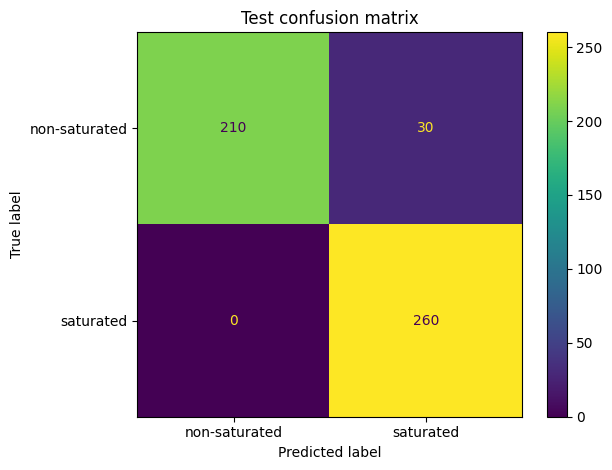

Number of test samples: 500
Number of errors: 30
Error rate: 0.0600


,true_label,predicted_label,probability_saturated,correct
0,0,0,0.016667,True
1,0,0,0.011111,True
2,0,0,0.016667,True
3,0,0,0.034445,True
4,0,0,0.034445,True
5,0,0,0.016667,True
6,0,0,0.013333,True
7,0,0,0.013333,True
8,0,0,0.011111,True
9,0,0,0.016667,True


,true_label,predicted_label,probability_saturated,correct
119,0,1,0.847561,False
120,0,1,0.857337,False
121,0,1,0.780116,False
122,0,1,0.733561,False
123,0,1,0.839449,False
124,0,1,0.836225,False
125,0,1,0.751784,False
126,0,1,0.829115,False
127,0,1,0.825115,False
128,0,1,0.811115,False


,true_label,predicted_label,count
0,0,1,30


,feature,importance
52,avg_ifs_ms,0.165760
25,x26,0.112207
53,collision_percentage,0.099451
20,x21,0.041770
17,x18,0.037789
5,x6,0.036519
19,x20,0.033051
21,x22,0.028729
10,x11,0.028451
12,x13,0.028271


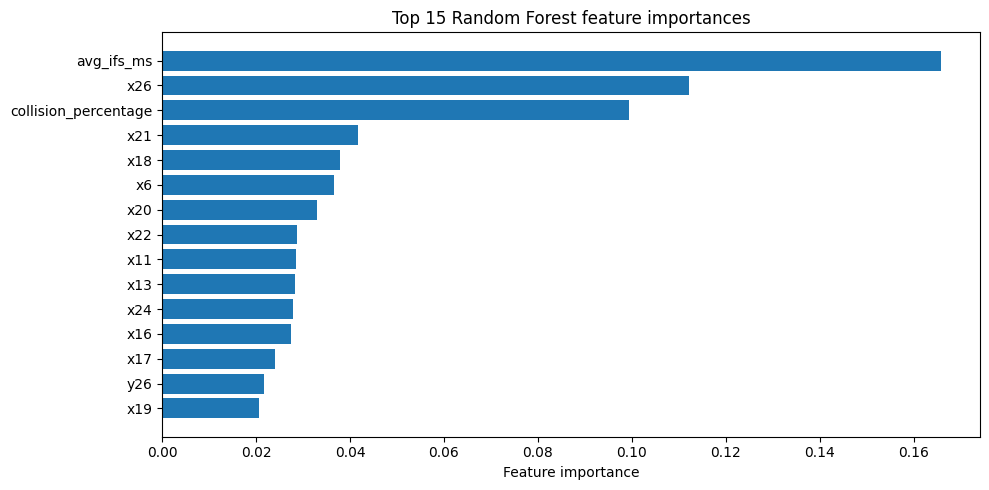

,importance
group,
IFS bin limits x1-x26,0.6035
Average IFS,0.1658
IFS histogram percentages y1-y26,0.1313
Collision percentage,0.0995


In [11]:
# (response to exercise 6)

# Load the independent test set. It was not used for the train/validation split.
test_file_name = mypath + '/test_data.csv'
test_data_df = pd.read_csv(test_file_name, header=None)
test_data_df.columns = all_columns
test_data_df[label_column] = test_data_df[label_column].astype(int)

X_test = test_data_df[feature_columns]
y_test = test_data_df[label_column]

test_metrics, test_pred, test_score = evaluate_binary_classifier(
    rf_model,
    X_test,
    y_test,
    dataset_name="Random forest test"
)

test_metrics_df = pd.DataFrame([test_metrics]).set_index("dataset").round(4)
display(test_metrics_df)

print("Classification report on the test set:")
print(classification_report(y_test, test_pred, digits=4))

cm_test = confusion_matrix(y_test, test_pred)

# Same format as before: rows are true labels, columns are predicted labels.
cm_test_df = pd.DataFrame(
    cm_test,
    index=["true non-saturated", "true saturated"],
    columns=["predicted non-saturated", "predicted saturated"]
)
display(cm_test_df)

ConfusionMatrixDisplay(cm_test, display_labels=["non-saturated", "saturated"]).plot(values_format="d")
plt.title("Test confusion matrix")
plt.tight_layout()
plt.show()

# Compare the predicted probability with the true label to inspect uncertain cases.
test_predictions = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_label": test_pred,
    "probability_saturated": test_score
})

test_predictions["correct"] = test_predictions["true_label"] == test_predictions["predicted_label"]
error_rate = 1 - test_predictions["correct"].mean()

print(f"Number of test samples: {len(test_predictions)}")
print(f"Number of errors: {(~test_predictions['correct']).sum()}")
print(f"Error rate: {error_rate:.4f}")

display(test_predictions.head(10))

# Inspect the first wrong predictions.
errors = test_predictions[test_predictions["correct"] == False]
display(errors.head(15))

# Count which type of mistake is made.
# This is useful because false alarms and missed saturated cases do not have the same meaning.
error_summary = (
    errors
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
)
display(error_summary)

# Feature importance helps connect the model decisions with the networking variables.
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance.head(15).sort_values("importance")["feature"],
    feature_importance.head(15).sort_values("importance")["importance"]
)
plt.xlabel("Feature importance")
plt.title("Top 15 Random Forest feature importances")
plt.tight_layout()
plt.show()

# Group the feature importances into interpretable blocks.
importance_groups = pd.DataFrame({
    "group": (
        ["IFS bin limits x1-x26"] * 26
        + ["IFS histogram percentages y1-y26"] * 26
        + ["Average IFS"]
        + ["Collision percentage"]
    ),
    "importance": rf_model.feature_importances_
}).groupby("group")["importance"].sum().sort_values(ascending=False)

display(importance_groups.to_frame().round(4))


**Exercise 6 final analysis**

On the independent test set, the Random Forest obtains **0.94 accuracy** and **0.9455 F1-score**. The model makes **30 errors out of 500 samples**, so the error rate is **6%**.

The most important point is the type of error. The test recall for the saturated class is **1.0000**, meaning that all saturated samples are detected. However, the precision for the saturated class is **0.8966**, which means that some non-saturated samples are predicted as saturated. In the confusion matrix, the 30 errors are false alarms: non-saturated cases classified as saturated. This is usually safer than the opposite error for congestion detection, because missing a saturated network would be more problematic than raising some false alerts.

The ROC-AUC and average precision are both equal to **1.0000**, while the accuracy is only **0.94**. This means that the model ranks the samples very well, but the default decision threshold still creates some false positives. A possible improvement would be to tune the probability threshold on the validation set if we wanted fewer false alarms.

The feature-importance results are also coherent with the task. The model mostly relies on the IFS bin limits, the average IFS and the histogram percentages. In this run, the grouped importances are about **0.6035** for the IFS bin limits, **0.1658** for average IFS, **0.1313** for the histogram percentages and **0.0995** for collision percentage. So the classifier is not only producing a good score: it is mainly using variables related to channel access delays, which is consistent with the idea of detecting Wi-Fi saturation.

## Final conclusion

This lab implements a supervised learning pipeline to detect saturated Wi-Fi networks from IFS-based features generated with ns-3.

The final Random Forest model performs well on the independent test set, with **94% accuracy** and **0.9455 F1-score**. More importantly, the model detects all saturated test samples in this run, so it does not miss any congested case. Its main weakness is that it sometimes predicts saturation for non-saturated samples.

From a networking point of view, this behaviour is still understandable: the model is conservative, because it prefers raising false alarms rather than missing saturation. The feature-importance analysis also makes the result easier to justify, since the most important variables are linked to the IFS distribution and the channel access process.